In [7]:
!pip3 install scikit-learn

In [9]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, BertModel
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

ImportError: dlopen(/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/__check_build/_check_build.cpython-310-darwin.so, 0x0002): tried: '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/__check_build/_check_build.cpython-310-darwin.so' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64')), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/__check_build/_check_build.cpython-310-darwin.so' (no such file), '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/__check_build/_check_build.cpython-310-darwin.so' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64'))
___________________________________________________________________________
Contents of /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sk

In [ ]:
# When run in google colab
# from google.colab import files
# from google.colab import drive
# drive.mount('/content/drive')

In [15]:
# Positive: your matched LGBTQ+ bills
lgbtq = pd.read_csv('../../datasources/final-outputs/matched_lgbtq_bills.csv')
lgbtq['label_id'] = 1

print(lgbtq.columns)

# Negative: random sample from unmatched LegiScan bills
all_bills = pd.read_csv('../../datasources/final-outputs/all_bills_2021_2026.csv')
non_lgbtq = all_bills[~all_bills['bill_id'].isin(lgbtq['bill_id'])].sample(
    n=len(lgbtq) * 2,
    random_state=42
)
non_lgbtq['label_id'] = 0

df = pd.concat([lgbtq, non_lgbtq]).sample(frac=1, random_state=42)
df['text'] = df['title'].fillna('') + '. ' + df['description'].fillna('')

print(f"Total bills: {len(df)}")
print(f"  LGBTQ+:     {(df['label_id']==1).sum()}")
print(f"  Non-LGBTQ+: {(df['label_id']==0).sum()}")
print(f"\nSample text:\n{df['text'].iloc[0]}")

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label_id']
)
print(f"\nTrain: {len(train_df)} ({train_df['label_id'].mean():.1%} LGBTQ+)")
print(f"Test:  {len(test_df)} ({test_df['label_id'].mean():.1%} LGBTQ+)")

Index(['state', 'bill_id', 'session_id', 'bill_number', 'status',
       'status_desc', 'status_date', 'title', 'description', 'committee_id',
       'committee', 'last_action_date', 'last_action', 'url', 'state_link',
       'sponsor_names', 'sponsor_parties', 'primary_sponsor', 'sponsor_count',
       'action_count', 'last_history_action', 'document_count', 'document_id',
       'document_type', 'document_url', 'rollcall_count', 'total_yea',
       'total_nay', 'year', 'r_sponsors', 'd_sponsors', 'other_sponsors',
       'bill_dominant_party', 'passed', 'failed', 'vetoed', 'state_lean',
       'r_sponsorship_ratio', 'pass_rate_gap', 'overall_pass_rate',
       'bipartisan_ratio', 'session_year', 'label', 'label_source', 'issues',
       'issue_categories', 'label_id'],
      dtype='object')


FileNotFoundError: [Errno 2] No such file or directory: '../../datasources/final-outputs/all_bills_2021_2026.csv'

In [ ]:
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = BertModel.from_pretrained(MODEL_NAME).to(device)

# Quick sanity check
test_inputs = tokenizer("An act prohibiting gender transition procedures for minors",
                       return_tensors="pt").to(device)
test_outputs = base_model(**test_inputs)
print(f"LegalBERT hidden size: {test_outputs.last_hidden_state.shape}")
# Should be [1, seq_len, 768]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LegalBERT hidden size: torch.Size([1, 10, 768])


In [ ]:
# 1. Token length distribution across ALL bills
token_lengths = []
for _, row in df.iterrows():
    text = str(row['text']).strip()
    if text:
        toks = tokenizer(text)['input_ids']
        token_lengths.append(len(toks))

token_lengths = np.array(token_lengths)

print("TOKEN LENGTH DISTRIBUTION")
print("=" * 50)
print(f"  Min:    {token_lengths.min()}")
print(f"  25th:   {np.percentile(token_lengths, 25):.0f}")
print(f"  Median: {np.percentile(token_lengths, 50):.0f}")
print(f"  75th:   {np.percentile(token_lengths, 75):.0f}")
print(f"  95th:   {np.percentile(token_lengths, 95):.0f}")
print(f"  Max:    {token_lengths.max()}")

# How many bills get truncated at each max_len?
for ml in [128, 256, 512]:
    truncated = (token_lengths > ml).sum()
    pct = truncated / len(token_lengths) * 100
    print(f"\n  max_len={ml}: {truncated}/{len(token_lengths)} bills truncated ({pct:.1f}%)")


# 2. Show a few examples: short, median, long
sorted_idx = np.argsort(token_lengths)
examples = {
    'Shortest': sorted_idx[0],
    'Median':   sorted_idx[len(sorted_idx)//2],
    'Longest':  sorted_idx[-1],
}

for name, idx in examples.items():
    row = df.iloc[idx]
    text = str(row['text']).strip()
    toks = tokenizer(text)['input_ids']
    decoded = tokenizer.convert_ids_to_tokens(toks)

    print(f"\n{'='*50}")
    print(f"{name} bill: {row.get('state','')} {row.get('bill_number','')} ({len(toks)} tokens)")
    print(f"Raw: {text[:200]}{'...' if len(text)>200 else ''}")
    print(f"Tokens: {' '.join(decoded[:40])}{'...' if len(decoded)>40 else ''}")

Token indices sequence length is longer than the specified maximum sequence length for this model (613 > 512). Running this sequence through the model will result in indexing errors


TOKEN LENGTH DISTRIBUTION
  Min:    7
  25th:   33
  Median: 49
  75th:   79
  95th:   189
  Max:    9489

  max_len=128: 610/6120 bills truncated (10.0%)

  max_len=256: 173/6120 bills truncated (2.8%)

  max_len=512: 48/6120 bills truncated (0.8%)

Shortest bill: NM HB3 (7 tokens)
Raw: Meat Inspections. Meat Inspections
Tokens: [CLS] meat inspections . meat inspections [SEP]

Median bill: AK HB119 (49 tokens)
Raw: Adult Foster Care For Disabled. An Act relating to medical assistance for recipients of adult foster care services; establishing an adult foster care home license and procedures; and providing for the...
Tokens: [CLS] adult foster care for disable ##d . an act relating to medical assistance for recipients of adult foster care services ; establishing an adult foster care home license and procedures ; and providing for the transition of individuals from...

Longest bill: OH HB96 (9489 tokens)
Raw: Make state operating appropriations for FY 2026-27. To amend sections 3.15, 9.0

In [ ]:
class BillDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = []
        for _, row in dataframe.iterrows():
            text = str(row['text']).strip()
            if not text:
                continue
            encoded = tokenizer(
                text,
                return_tensors='pt',
                max_length=max_len,
                truncation=True,
                padding='max_length',
            )
            self.data.append({
                'input_ids': encoded['input_ids'].squeeze(0).to(device),
                'attention_mask': encoded['attention_mask'].squeeze(0).to(device),
                'label': torch.tensor(row['label_id'], dtype=torch.float32, device=device),
            })
        print(f"  Loaded {len(self.data)} examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


MAX_LEN = 256

print("Building train set...")
train_data = BillDataset(train_df, tokenizer, max_len=MAX_LEN)
print("Building test set...")
test_data = BillDataset(test_df, tokenizer, max_len=MAX_LEN)

Building train set...
  Loaded 4896 examples
Building test set...
  Loaded 1224 examples


In [ ]:
class LegalBERTClassifier(torch.nn.Module):
    def __init__(self, bert_model, hidden_size=768, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.dropout = torch.nn.Dropout(dropout)
        self.linear = torch.nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask=None):
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state
        cls_output = bert_output[:, 0, :]
        cls_output = self.dropout(cls_output)
        logit = self.linear(cls_output)
        return torch.squeeze(logit)


model = LegalBERTClassifier(base_model).to(device)

# No class weighting needed — 2:1 ratio is mild enough
loss_fn = torch.nn.BCEWithLogitsLoss()

BATCH_SIZE = 8
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
batch = next(iter(train_loader))
out = model(batch['input_ids'], batch['attention_mask'])
loss = loss_fn(out, batch['label'])
print(f"Sanity check — output: {out.shape}, loss: {loss.item():.4f}")

Sanity check — output: torch.Size([8]), loss: 0.8372


In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer, reporting_interval=50):
    model.train()
    epoch_loss, total_batches = 0, 0

    for batch_idx, data in enumerate(dataloader):
        optimizer.zero_grad()
        outputs = model(data['input_ids'], data['attention_mask'])
        loss = loss_fn(outputs, data['label'])
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total_batches += 1

        if (batch_idx + 1) % reporting_interval == 0:
            print(
                f"  Batch {batch_idx + 1}: avg loss = {epoch_loss / total_batches:.4f}")

    print(f"  Train loss: {epoch_loss / max(total_batches, 1):.4f}")


def eval_loop(dataloader, model, loss_fn):
    model.eval()
    test_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for data in dataloader:
            outputs = model(data['input_ids'], data['attention_mask'])
            test_loss += loss_fn(outputs, data['label']).item()

            preds = torch.round(torch.sigmoid(outputs))
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(data['label'].cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(
        f"  Test loss: {test_loss / len(dataloader):.4f}, Accuracy: {100 * accuracy:.1f}%")
    print("\n" + classification_report(
        all_labels, all_preds,
        target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
    ))

In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

print("Phase 1: Classifier head only\n")
for epoch in range(3):
    print(f"Epoch {epoch + 1}/3")
    train_loop(train_loader, model, loss_fn, optimizer)
    eval_loop(test_loader, model, loss_fn)
    print()

# Phase 2: Unfreeze last 2 BERT layers
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Phase 2: Fine-tuning last 2 layers\n")
for epoch in range(2):
    print(f"Epoch {epoch + 1}/2")
    train_loop(train_loader, model, loss_fn, optimizer)
    eval_loop(test_loader, model, loss_fn)
    print()

print("Done!")

Phase 1: Classifier head only

Epoch 1/3
  Batch 50: avg loss = 0.6935
  Batch 100: avg loss = 0.6735
  Batch 150: avg loss = 0.6587
  Batch 200: avg loss = 0.6463
  Batch 250: avg loss = 0.6453
  Batch 300: avg loss = 0.6412
  Batch 350: avg loss = 0.6374
  Batch 400: avg loss = 0.6319
  Batch 450: avg loss = 0.6284
  Batch 500: avg loss = 0.6280
  Batch 550: avg loss = 0.6261
  Batch 600: avg loss = 0.6255
  Train loss: 0.6250
  Test loss: 0.5930, Accuracy: 68.0%

              precision    recall  f1-score   support

  non-LGBTQ+      0.677     0.995     0.806       816
      LGBTQ+      0.833     0.049     0.093       408

    accuracy                          0.680      1224
   macro avg      0.755     0.522     0.449      1224
weighted avg      0.729     0.680     0.568      1224


Epoch 2/3
  Batch 50: avg loss = 0.5950
  Batch 100: avg loss = 0.5903
  Batch 150: avg loss = 0.5817
  Batch 200: avg loss = 0.5810
  Batch 250: avg loss = 0.5791
  Batch 300: avg loss = 0.5758
  Batc

In [ ]:
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for data in test_loader:
        outputs = model(data['input_ids'], data['attention_mask'])
        # Apply sigmoid to convert logits → probabilities
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(data['label'].cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# F1 at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold:.3f}")

# Compare thresholds
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (all_probs >= t).astype(int)
    print(f"\nThreshold = {t}:")
    print(classification_report(all_labels, preds,
          target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3))

Best F1 threshold: 0.427

Threshold = 0.3:
              precision    recall  f1-score   support

  non-LGBTQ+      0.931     0.924     0.927       816
      LGBTQ+      0.850     0.863     0.856       408

    accuracy                          0.904      1224
   macro avg      0.891     0.893     0.892      1224
weighted avg      0.904     0.904     0.904      1224


Threshold = 0.4:
              precision    recall  f1-score   support

  non-LGBTQ+      0.925     0.939     0.932       816
      LGBTQ+      0.874     0.848     0.861       408

    accuracy                          0.908      1224
   macro avg      0.899     0.893     0.896      1224
weighted avg      0.908     0.908     0.908      1224


Threshold = 0.5:
              precision    recall  f1-score   support

  non-LGBTQ+      0.913     0.953     0.933       816
      LGBTQ+      0.898     0.819     0.856       408

    accuracy                          0.908      1224
   macro avg      0.905     0.886     0.895      

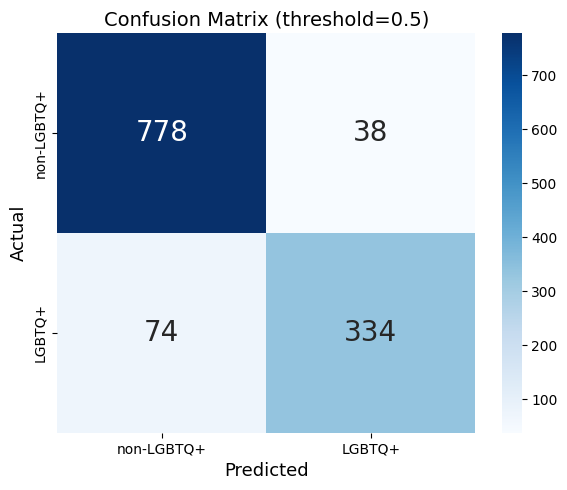

              precision    recall  f1-score   support

  non-LGBTQ+      0.913     0.953     0.933       816
      LGBTQ+      0.898     0.819     0.856       408

    accuracy                          0.908      1224
   macro avg      0.905     0.886     0.895      1224
weighted avg      0.908     0.908     0.907      1224



In [ ]:
THRESHOLD = 0.5

all_preds = (all_probs >= THRESHOLD).astype(int)

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-LGBTQ+', 'LGBTQ+'],
            yticklabels=['non-LGBTQ+', 'LGBTQ+'],
            annot_kws={'size': 20}, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.show()

print(classification_report(
    all_labels, all_preds,
    target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
))